In [69]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import numpy as np 
import pandas as pd
import sklearn

In [71]:
data=pd.DataFrame({'Price_USA':[80,50,140,25],'Price_INR':[5000,7000,12000,3000]})
data

,Price_USA,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [72]:
data['Price_USA_minmax'] = (data['Price_USA'] - data['Price_USA'].min())/(data['Price_USA'].min())
data

,Price_USA,Price_INR,Price_USA_minmax
0,80,5000,2.2
1,50,7000,1.0
2,140,12000,4.6
3,25,3000,0.0


In [73]:
import sklearn

In [74]:
from sklearn .preprocessing import MinMaxScaler,StandardScaler

In [75]:
min_max = MinMaxScaler()

In [76]:
data['Price_USA_minsk'] = min_max.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk
0,80,5000,2.2,0.222222
1,50,7000,1.0,0.444444
2,140,12000,4.6,1.000000
3,25,3000,0.0,0.000000


In [77]:
data['Price_USA_std'] =(data['Price_USA'] - data['Price_USA'].mean())
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk,Price_USA_std
0,80,5000,2.2,0.222222,6.25
1,50,7000,1.0,0.444444,-23.75
2,140,12000,4.6,1.000000,66.25
3,25,3000,0.0,0.000000,-48.75


In [78]:
data['Price_USA_std'] = (data['Price_USA'] - data['Price_USA'].mean()) / (data['Price_USA'].std())
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk,Price_USA_std
0,80,5000,2.2,0.222222,0.126108
1,50,7000,1.0,0.444444,-0.479212
2,140,12000,4.6,1.000000,1.336748
3,25,3000,0.0,0.000000,-0.983645


In [79]:
from sklearn.preprocessing import StandardScaler

In [80]:
scaler=StandardScaler()

In [81]:
data['Price_USA_Scaler']=scaler.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk,Price_USA_std,Price_USA_Scaler
0,80,5000,2.2,0.222222,0.126108,0.145617
1,50,7000,1.0,0.444444,-0.479212,-0.553346
2,140,12000,4.6,1.000000,1.336748,1.543544
3,25,3000,0.0,0.000000,-0.983645,-1.135815


In [82]:
data['Price_INR_Scaler']=scaler.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_USA_minsk,Price_USA_std,Price_USA_Scaler,Price_INR_Scaler
0,80,5000,2.2,0.222222,0.126108,0.145617,-0.523205
1,50,7000,1.0,0.444444,-0.479212,-0.553346,0.074744
2,140,12000,4.6,1.000000,1.336748,1.543544,1.569614
3,25,3000,0.0,0.000000,-0.983645,-1.135815,-1.121153


In [83]:
from sklearn.preprocessing import RobustScaler

In [84]:
robust=RobustScaler()

In [85]:
data['Price_USA_robust']=robust.fit_transform(data[['Price_USA']])
data['Price_USA_robust']
data['Price_INR_robust']=robust.fit_transform(data[['Price_INR']])
data['Price_INR_robust']

0   -0.266667
1    0.266667
2    1.600000
3   -0.800000
Name: Price_INR_robust, dtype: float64

In [86]:
!pip3 install ucimlrepo


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
sns.set_style(style='whitegrid')

In [90]:
data = fetch_ucirepo(id=9)
data
X= data.data.features.copy()
X
y=data.data.targets['mpg']
y


0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [91]:
!where python

C:\Users\narag\ml_workshop_env\Scripts\python.exe
C:\Users\narag\AppData\Local\Microsoft\WindowsApps\python.exe


In [92]:
X['origin'].unique();
X['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [93]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [94]:
X['horsepower']=pd.to_numeric(X['horsepower'],errors='coerce')
X['origin']=X['origin'].astype(str)

In [95]:
X.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 22.3 KB


In [96]:
numerical_features = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
categorical_features = ['origin']
X=X[numerical_features + categorical_features]
#X.info()
#X.isnull().sum()
X.shape

(398, 7)

In [97]:
df=X.copy()
df['mpg']=y

Text(0.5, 1.0, 'Horsepower vs MPG Distribution')

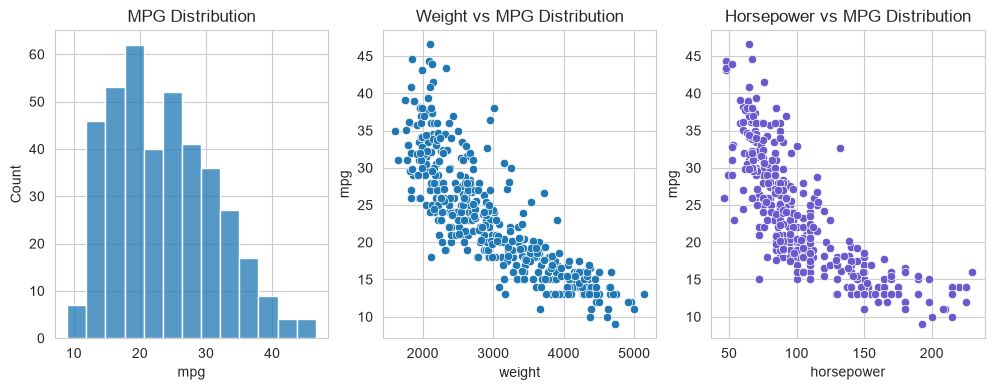

In [98]:
#df
fig,axes=plt.subplots(1,3,figsize=(12,4))
sns.histplot(df['mpg'],kde=False,ax=axes[0])
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'],y=df['mpg'],ax=axes[1])
axes[1].set_title("Weight vs MPG Distribution")
sns.scatterplot(x=df['horsepower'],y=df['mpg'],ax=axes[2],color='slateblue')
axes[2].set_title("Horsepower vs MPG Distribution")


<Axes: >

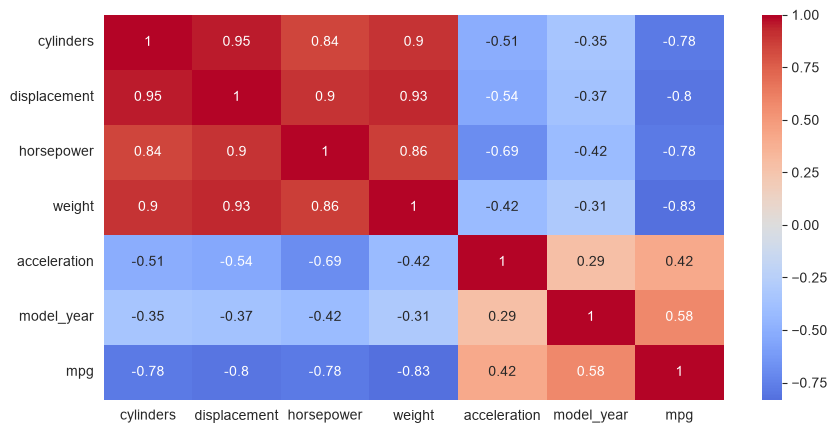

In [99]:
plt.figure(figsize=(10,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap='coolwarm',center=0)

In [100]:
#print(X)
print(y)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print('\n Train Test Split')
print("Training Data",len(X_train))
print("Testing Data",len(X_test))
print(X_train)

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

 Train Test Split
Training Data 318
Testing Data 80
     cylinders  displacement  horsepower  weight  acceleration  model_year  \
3            8         304.0       150.0    3433          12.0          70   
18           4          97.0        88.0    2130          14.5          70   
376          4          91.0        68.0    2025          18.2          82   
248          4          91.0        60.0    1800          16.4          78   
177          4         115.0        95.0    2694          15.0          75   
..         ...           ...         ...     ...           ...         ...   
71           3          70.0        97.0    2330          13.5          72   
106          8         350.0       180.0    4499          12.5          73   
270          4         134.0        95.0    2515          14.8          78

In [107]:
def evaluate(model_name,actual,predicted):
    """Returns MAE,MSE,RMSE,R2-Score"""
    mse = mean_squared_error(actual,predicted)
    mae = mean_absolute_error(actual,predicted)
    return {'Model_Name': model_name,
    'MAE':mae,
    'MSE':mse,
    'RMSE':np.sqrt(mse),
    'R2-Score':r2_score(actual,predicted)}
result =[]

In [108]:
baseline_predictions =np.full(len(y_test),y_train.mean())
#baseline_predictions
results.append(evaluate("Mean baseline",y_test,baseline_predictions))
#results

In [109]:
simple_model = LinearRegression()
simple_model.fit(X_train[['weight']],y_train)
simple_model_predictions = simple_model.predict(X_test[['weight']])
results.append(evaluate("Simple Linear Regression:Weight",y_test,simple_model_predictions))
print(len(results))

11


In [110]:
results

[{'Model_Name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686},
 {'Model_Name': 'Simple Linear Regression:Weight',
  'MAE': 3.1177861992064573,
  'MSE': 14.894861064636197,
  'RMSE': np.float64(3.859386099451077),
  'R2-Score': 0.722971057303075},
 {'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.9832

In [112]:
print(f'Simple Linear Regression Equation')
print(f"Predicted MPG = {simple_model.intercept_}+({simple_model.coef_[0]})*weight")

Simple Linear Regression Equation
Predicted MPG = 46.78206336645047+(-0.007805242351594879)*weight
